# SplineNAM: Additive cubic spline network

SplineNAM replaces feature MLPs with trainable cubic spline layers. Scalar preprocessing and optional identifiability centering keep each learned shape interpretable.


## Model in one view


$$
f_j(x_j)=\sum_{k=1}^{K}\theta_{jk}B_{jk}(x_j),
\qquad
\eta(x)=\beta_0+\sum_jf_j(x_j),
$$

with optional roughness control proportional to squared adjacent coefficient differences.



SplineNAM expands each scalar input in a compact cubic B-spline basis and learns
the coefficients by gradient descent. Local basis support makes shapes cheaper
and more structured than general MLP subnetworks. A difference penalty on
neighboring coefficients discourages rapid oscillation.

Unlike statistical GAM smoothing selection, the smoothing weight is a neural
training hyperparameter rather than a REML/GCV-estimated variance component.
Identifiability centering fixes each term's additive constant. Learnable knots
increase flexibility but make the basis itself part of the nonconvex fit.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = ["#2563EB", "#F97316", "#10B981", "#8B5CF6", "#EF4444"]

rng = np.random.default_rng(7)
n = 180
X = pd.DataFrame({
    "x1": rng.uniform(-1.0, 1.0, n),
    "x2": rng.normal(size=n),
    "group": rng.choice(["a", "b", "c"], size=n),
})
y = (
    np.sin(np.pi * X["x1"])
    + 0.35 * X["x2"] ** 2
    + 0.30 * (X["group"] == "b")
    + rng.normal(0.0, 0.12, n)
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=7
)


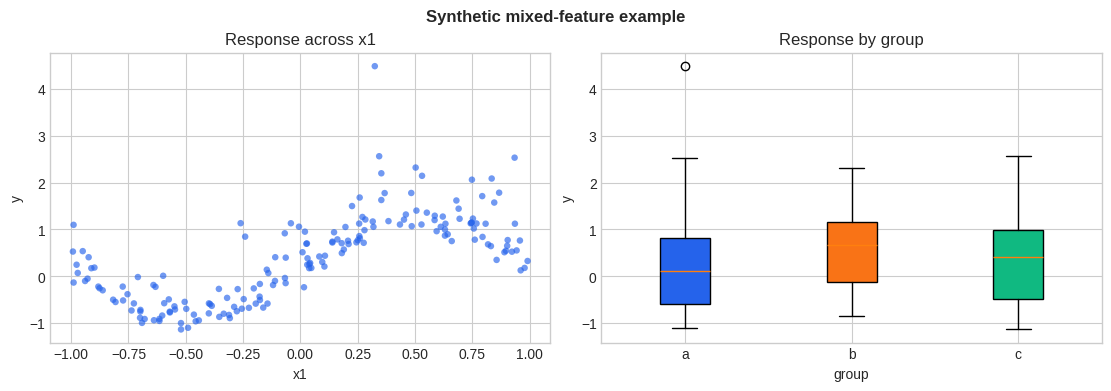

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)
axes[0].scatter(X["x1"], y, s=22, alpha=0.65, color=COLORS[0], edgecolor="none")
axes[0].set(title="Response across x1", xlabel="x1", ylabel="y")

group_order = ["a", "b", "c"]
group_values = [y[X["group"].to_numpy() == level] for level in group_order]
boxes = axes[1].boxplot(group_values, tick_labels=group_order, patch_artist=True)
for patch, color in zip(boxes["boxes"], COLORS, strict=False):
    patch.set_facecolor(color)
axes[1].set(title="Response by group", xlabel="group", ylabel="y")
fig.suptitle("Synthetic mixed-feature example", fontweight="bold")
plt.show()
plt.close(fig)


## Fit the model


In [3]:
from nampy.models import SplineNAMRegressor


model = SplineNAMRegressor(
    n_knots=10,
    learn_knots=False,
    identify=True,
    smoothing=1e-3,
    interactions=(("x1", "x2"),),
)
model.get_params(deep=False)


{'dropout': 0.1,
 'feature_dropout': 0.0,
 'identify': True,
 'interaction_degree': None,
 'interactions': (('x1', 'x2'),),
 'intercept': True,
 'learn_knots': False,
 'lr': 0.0001,
 'lr_factor': 0.1,
 'lr_patience': 10,
 'n_knots': 10,
 'smoothing': 0.001,
 'weight_decay': 1e-06,
 'feature_preprocessing': None,
 'n_bins': 64,
 'numerical_preprocessing': 'minmax',
 'categorical_preprocessing': 'int',
 'use_decision_tree_bins': False,
 'binning_strategy': 'uniform',
 'task': 'regression',
 'cat_cutoff': 0.03,
 'treat_all_integers_as_numerical': False,
 'degree': 3,
 'scaling_strategy': None,
 'use_decision_tree_knots': True,
 'knots_strategy': 'uniform',
 'spline_implementation': 'sklearn',
 'min_unique_vals': 5}

In [4]:
model.fit(
    X_train,
    y_train,
    max_epochs=3,
    batch_size=64,
    random_state=7,
    logger=False,
    enable_progress_bar=False,
    enable_model_summary=False,
)
predictions = model.predict(X_test)
r2 = model.score(X_test, y_test)
metrics = model.evaluate(X_test, y_test)
components = model.predict_components(X_test)
explanation = model.explain_terms(X_test, max_bins=24, center=True)
importance = model.term_importance(X_test, center=True)
interaction_importance = model.interaction_importance(X_test, center=True)
display({"R2": r2, **metrics})
display(importance)
display(explanation.head(12))


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


/opt/hostedtoolcache/Python/3.11.16/x64/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.
/opt/hostedtoolcache/Python/3.11.16/x64/lib/python3.11/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('val_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/opt/hostedtoolcache/Python/3.11.16/x64/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.
/opt/hostedtoolcache/Python/3.11.16/x64/lib/python3.11/site-packages/lightning/pytorch/core/m

{'R2': -0.06553755543491313, 'Mean Squared Error': 0.7436473589168364}

,term,term_type,output,importance
0,x2,main,0,0.140538
1,x1:x2,interaction,0,0.080344
2,x1,main,0,0.077036
3,group,main,0,0.033167


,term,term_type,output,value,value_2,contribution,count,importance
0,x1,main,0,-0.965,NaN,0.039338,2,0.077036
1,x1,main,0,-0.8895,NaN,-0.015115,2,0.077036
2,x1,main,0,-0.7905,NaN,-0.142649,2,0.077036
3,x1,main,0,-0.6915,NaN,-0.051658,2,0.077036
4,x1,main,0,-0.58,NaN,0.114912,2,0.077036
5,x1,main,0,-0.4875,NaN,0.211364,2,0.077036
6,x1,main,0,-0.35,NaN,0.047142,1,0.077036
7,x1,main,0,-0.209,NaN,-0.005915,2,0.077036
8,x1,main,0,-0.12505,NaN,-0.112814,2,0.077036
9,x1,main,0,-0.05205,NaN,-0.104604,2,0.077036


## Evaluate and explain


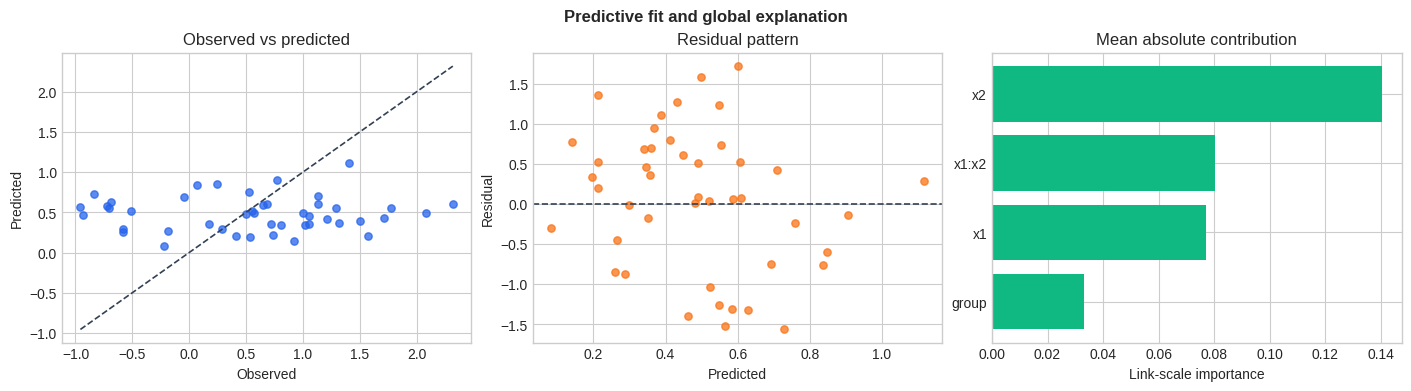

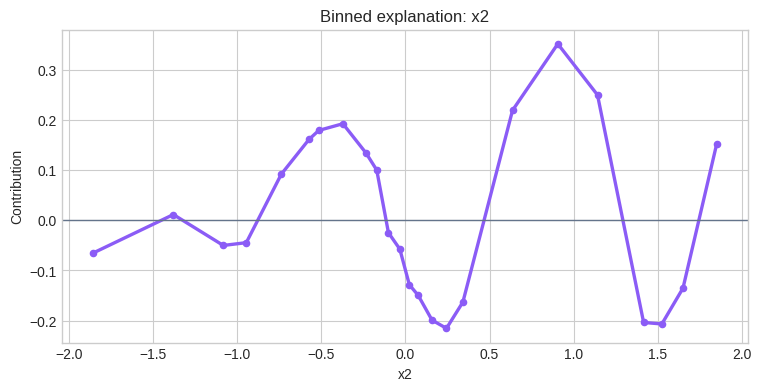

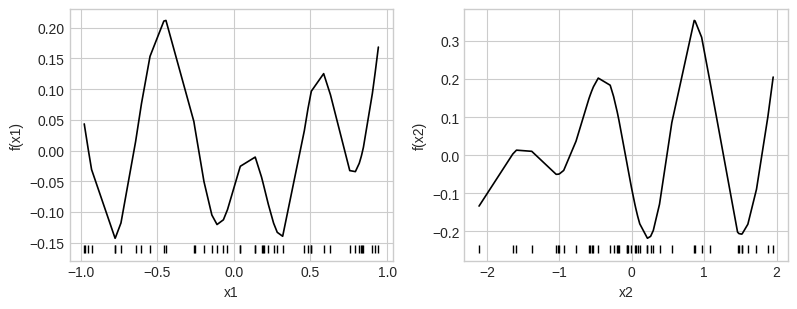

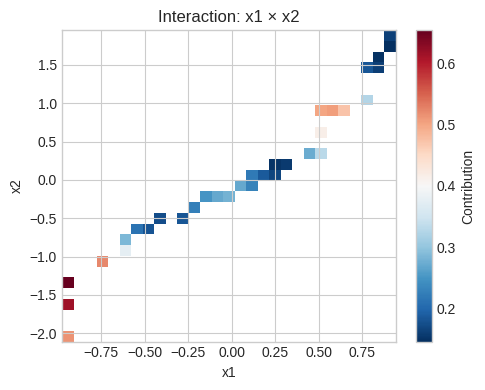

In [5]:
observed = np.asarray(y_test).reshape(-1)
fitted = np.asarray(predictions).reshape(-1)
residual = observed - fitted

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), constrained_layout=True)
axes[0].scatter(observed, fitted, s=28, alpha=0.75, color=COLORS[0])
lo = min(observed.min(), fitted.min())
hi = max(observed.max(), fitted.max())
axes[0].plot([lo, hi], [lo, hi], "--", color="#334155", linewidth=1.2)
axes[0].set(title="Observed vs predicted", xlabel="Observed", ylabel="Predicted")

axes[1].scatter(fitted, residual, s=28, alpha=0.75, color=COLORS[1])
axes[1].axhline(0.0, color="#334155", linestyle="--", linewidth=1.2)
axes[1].set(title="Residual pattern", xlabel="Predicted", ylabel="Residual")

importance_plot = (
    importance.groupby("term", as_index=False)["importance"]
    .mean()
    .sort_values("importance")
)
axes[2].barh(importance_plot["term"], importance_plot["importance"], color=COLORS[2])
axes[2].set(title="Mean absolute contribution", xlabel="Link-scale importance")
fig.suptitle("Predictive fit and global explanation", fontweight="bold")
plt.show()
plt.close(fig)

main_effects = explanation.loc[
    (explanation["term_type"] == "main") & (explanation["output"] == 0)
].copy()
main_effects["numeric_value"] = pd.to_numeric(main_effects["value"], errors="coerce")
main_effects = main_effects.dropna(subset=["numeric_value"])
if not main_effects.empty:
    numeric_terms = set(main_effects["term"])
    top_term = next(
        term
        for term in importance_plot.sort_values("importance", ascending=False)["term"]
        if term in numeric_terms
    )
    curve = main_effects.loc[main_effects["term"] == top_term].sort_values("numeric_value")
    if not curve.empty:
        fig, ax = plt.subplots(figsize=(7.5, 3.8), constrained_layout=True)
        ax.plot(curve["numeric_value"], curve["contribution"], color=COLORS[3], linewidth=2.4)
        ax.scatter(curve["numeric_value"], curve["contribution"], s=20, color=COLORS[3])
        ax.axhline(0.0, color="#64748B", linewidth=1)
        ax.set(title=f"Binned explanation: {top_term}", xlabel=top_term, ylabel="Contribution")
        plt.show()
        plt.close(fig)

term_figures = model.plot_terms(X_test, center=True, rug=True, pages=1)
interaction_terms = interaction_importance["term"].astype(str).tolist()
interactions_are_raw_columns = all(
    all(
        part in X_test.columns
        and pd.api.types.is_numeric_dtype(X_test[part])
        for part in term.split(":")
    )
    for term in interaction_terms
)
if interaction_terms and interactions_are_raw_columns:
    model.plot_interactions(X_test)


## Model-specific controls

`n_knots` controls basis resolution, `learn_knots` makes locations trainable, and `identify` centers shapes. SplineNAM requires scalar transformed features.


,term,term_type,output,importance
0,x1:x2,interaction,0,0.276893
1,x1,main,0,0.223485
2,x2,main,0,0.164329
3,group,main,0,0.088960


{'total_parameters': 45, 'trainable_parameters': 45}

[<Figure size 800x320 with 2 Axes>]

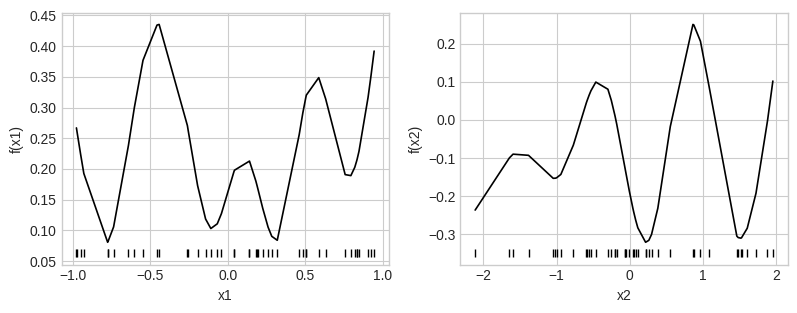

In [6]:
display(model.term_importance(X_test))
display(model.model_complexity())
model.plot_terms(X_test, pages=1)


## Supported task variants

The current public surface is `SplineNAMRegressor`; classification and LSS are deliberately unsupported.


In [7]:
task_variants = {"regression": model}


## References

- Eilers and Marx (1996), Flexible smoothing with B-splines and penalties.
